This notebook is dedicated to data visualization of the Iris dataset. It includes graphs such as scatter plots for sepal length and width, and petal length and width using Matplotlib, Pandas DataFrame, and Seaborn. It also features histograms, violin plots, heatmaps, and line plots for the Iris dataset

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
data = pd.read_csv(r"Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris_setosa
1,2,4.9,3.0,1.4,0.2,Iris_setosa
2,3,4.7,3.2,1.3,0.2,Iris_setosa
3,4,4.6,3.1,1.5,0.2,Iris_setosa
4,5,5.0,3.6,1.4,0.2,Iris_setosa


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Data Cleaning

In [7]:
data.drop('Id', axis= 1, inplace= True)  

In [8]:
data.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
107,7.3,2.9,6.3,1.8,Iris_virginica
59,5.2,2.7,3.9,1.4,Iris_versicolor
20,5.4,3.4,1.7,0.2,Iris_setosa
109,7.2,3.6,6.1,2.5,Iris_virginica
38,4.4,3.0,1.3,0.2,Iris_setosa


Exploratory Data Analysis

Univariate Analysis

Histogram for all the features

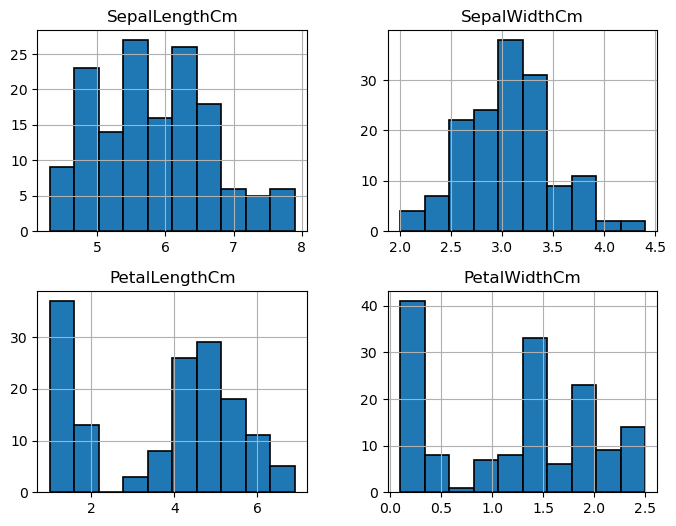

In [23]:
data.hist(edgecolor = 'black', linewidth = 1.2 )
fig = plt.gcf()
fig.set_size_inches(8,6)
plt.show()

Boxplot for all the features

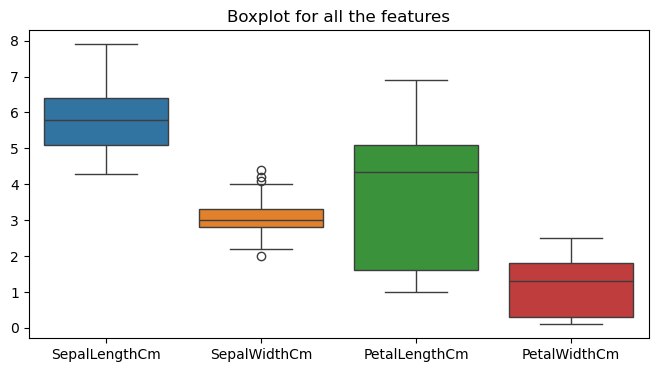

In [33]:
plt.figure(figsize = (8, 4))
sns.boxplot(data  = data)
plt.title("Boxplot for all the features")
plt.show()


Let's see the distribution between the length and width

Let's see how the length  and width vary according to species

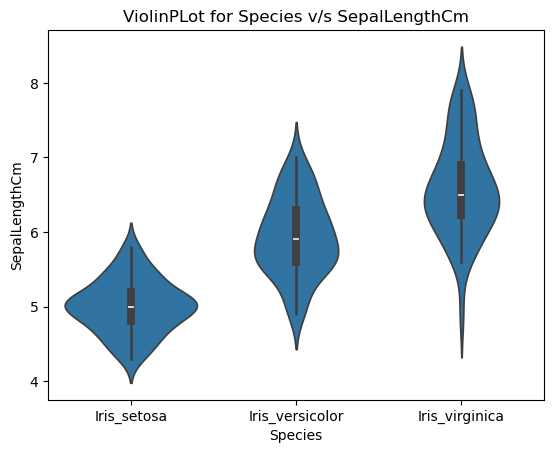

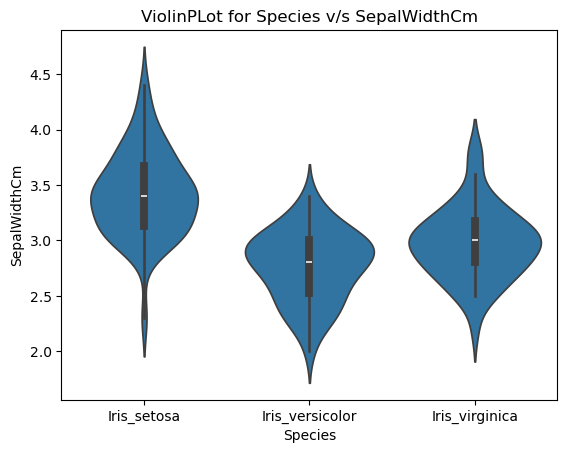

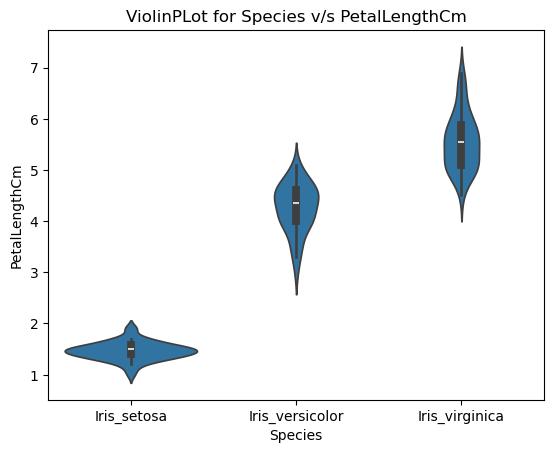

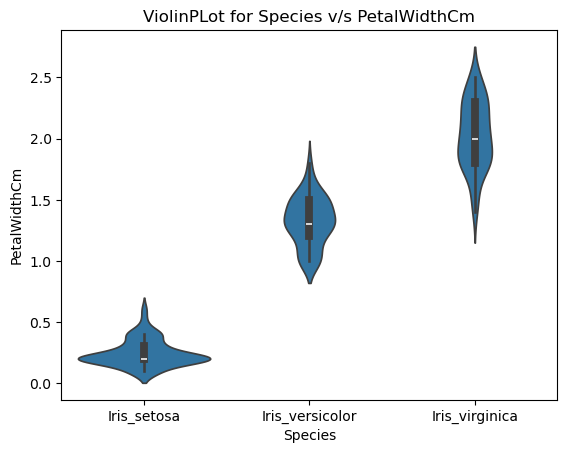

In [ ]:
for col in data.columns[:4]:
    sns.violinplot(x = 'Species', y= col, data = data)
    plt.title(f"ViolinPLot for Species v/s {col}")
    plt.show()

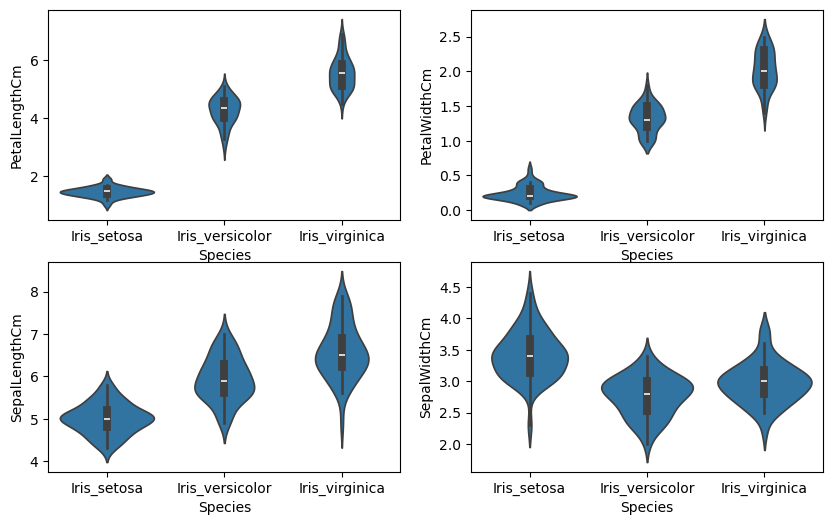

In [29]:
plt.figure(figsize= (10, 6))
plt.subplot(2, 2, 1)
sns.violinplot(x = 'Species', y = 'PetalLengthCm', data = data )
plt.subplot(2, 2, 2)
sns.violinplot(x = 'Species', y = 'PetalWidthCm',   data = data)
plt.subplot(2, 2, 3)
sns.violinplot(x = 'Species', y = 'SepalLengthCm', data = data)
plt.subplot(2, 2, 4)
sns.violinplot(x = 'Species', y = 'SepalWidthCm', data = data)
plt.show()


The violinplot shows the density of the length and width in the Species. The thinner part denotes that there is less density whereas the fatter part conveys higher density.

Bivariate Analysis

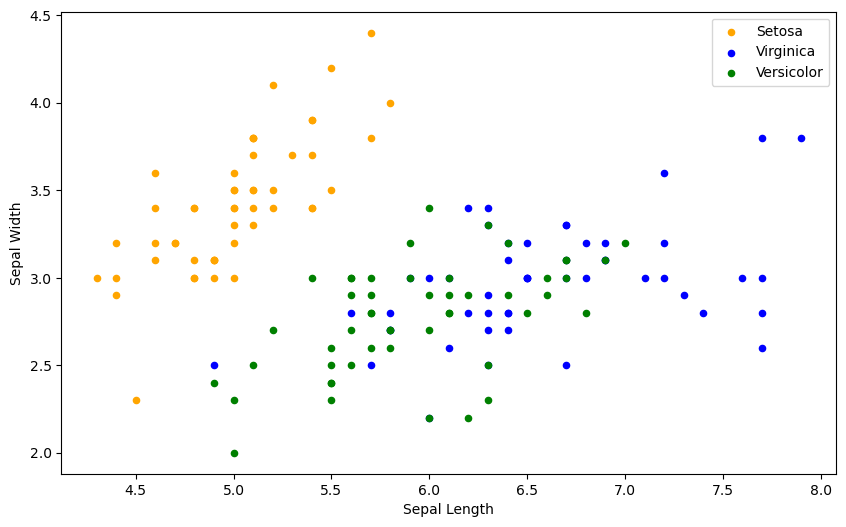

In [13]:
fig = data[data.Species == "Iris_setosa"].plot(kind = 'scatter', x = 'SepalLengthCm', y = 'SepalWidthCm', color = 'orange', label = 'Setosa')
data[data.Species == 'Iris_virginica'].plot(kind = 'scatter', x = 'SepalLengthCm', y = 'SepalWidthCm', color = 'blue', label = 'Virginica', ax = fig)
data[data.Species == 'Iris_versicolor'].plot(kind = 'scatter', x = 'SepalLengthCm', y = 'SepalWidthCm', color = 'green', label = 'Versicolor', ax = fig)
fig.set_xlabel("Sepal Length")
fig.set_ylabel("Sepal Width")
#fig.set_title('Sepal Length v/s Width')
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.show()

In [16]:
data.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
40,5.0,3.5,1.3,0.3,Iris_setosa
95,5.7,3.0,4.2,1.2,Iris_versicolor
62,6.0,2.2,4.0,1.0,Iris_versicolor
90,5.5,2.6,4.4,1.2,Iris_versicolor
119,6.0,2.2,5.0,1.5,Iris_virginica


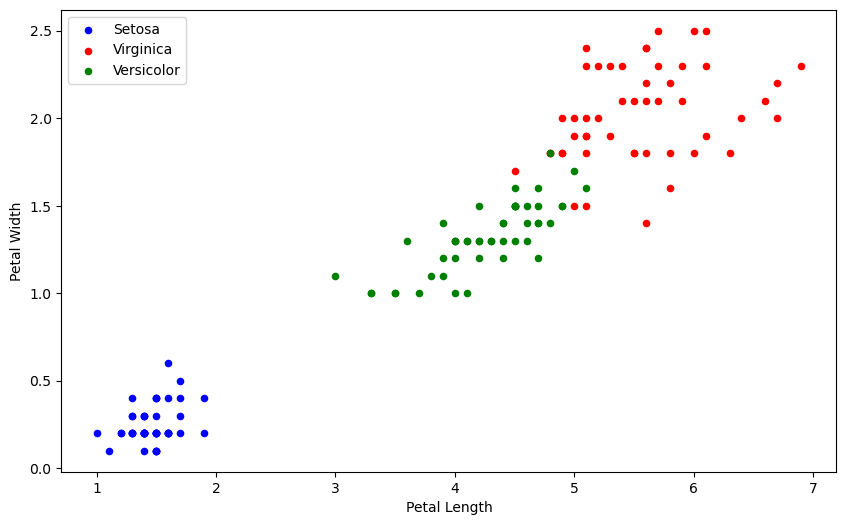

In [22]:
fig = data[data.Species == 'Iris_setosa'].plot(kind = 'scatter',  x = 'PetalLengthCm', y = "PetalWidthCm", color = 'blue', label = "Setosa")
data[data.Species == 'Iris_virginica'].plot(kind = 'scatter', x = 'PetalLengthCm', y = 'PetalWidthCm', color = 'red', label = 'Virginica', ax = fig)
data[data.Species == 'Iris_versicolor'].plot(kind = 'scatter', x = 'PetalLengthCm', y = 'PetalWidthCm', color = 'green', label = 'Versicolor', ax = fig)
fig.set_xlabel("Petal Length")
fig.set_ylabel("Petal Width")
fig = plt.gcf()
#fig.set_title('Petal Length v/s Width')
fig.set_size_inches(10, 6)
plt.show()

##### Conclusion:
Petal features are giving a better cluster division compare to the sepal features. This is indication that the petal features can help in better and accurate Predictions over the Sepal features.

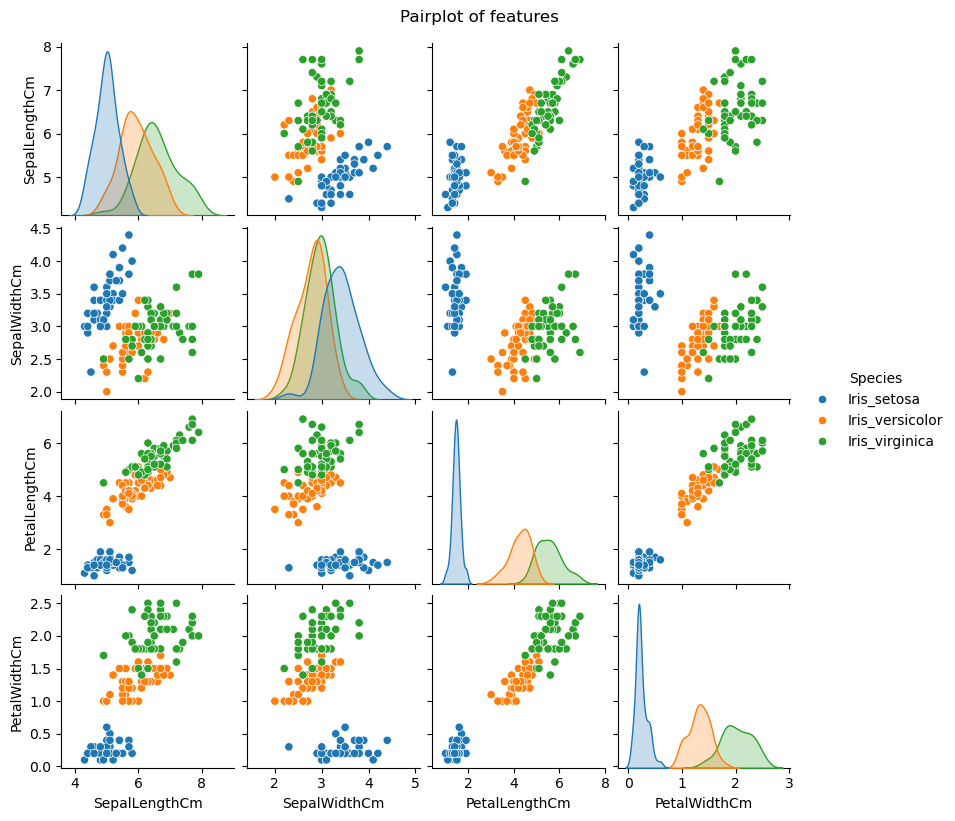

In [45]:
sns.pairplot(data, hue = 'Species', height= 2)
plt.suptitle("Pairplot of features", y = 1.02)
plt.show()

Correlation Matrix


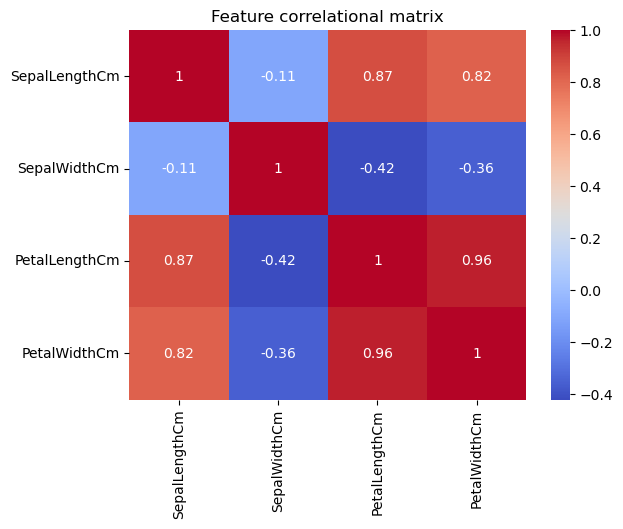

In [47]:
corr = data.iloc[:, :-1].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Feature correlational matrix")
plt.show()

Outliers detection

In [52]:
data.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
22,4.6,3.6,1.0,0.2,Iris_setosa
129,7.2,3.0,5.8,1.6,Iris_virginica
73,6.1,2.8,4.7,1.2,Iris_versicolor
114,5.8,2.8,5.1,2.4,Iris_virginica
119,6.0,2.2,5.0,1.5,Iris_virginica


In [53]:
data['Species'] = data['Species'].map({'Iris_setosa': 1, 'Iris_virginica': 2, 'Iris_versicolor': 3 })

In [54]:
data.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
102,7.1,3.0,5.9,2.1,2
52,6.9,3.1,4.9,1.5,3
92,5.8,2.6,4.0,1.2,3
5,5.4,3.9,1.7,0.4,1
147,6.5,3.0,5.2,2.0,2


In [55]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((data < (Q1 - 1.5 *  IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
outliers

SepalLengthCm    0
SepalWidthCm     4
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Features Distributions (KDE plots)


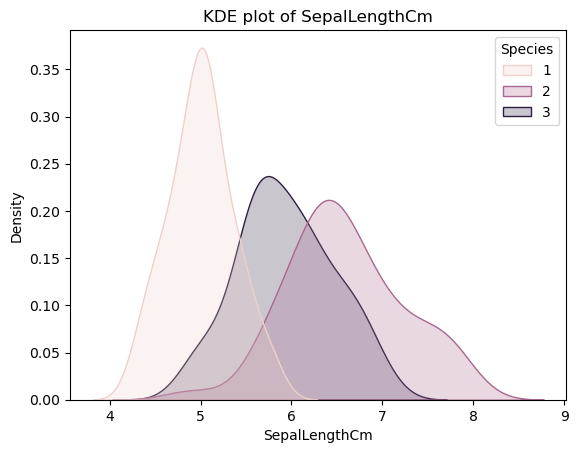

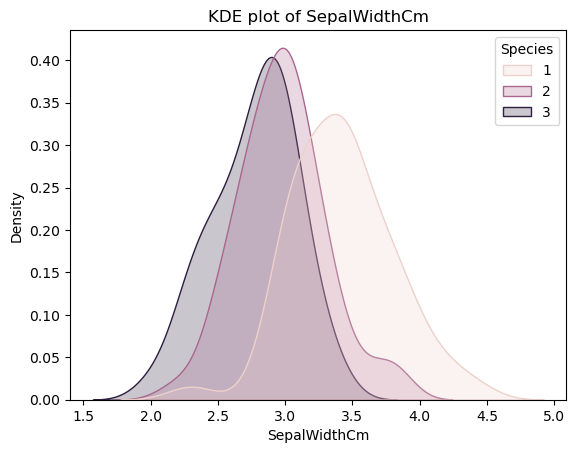

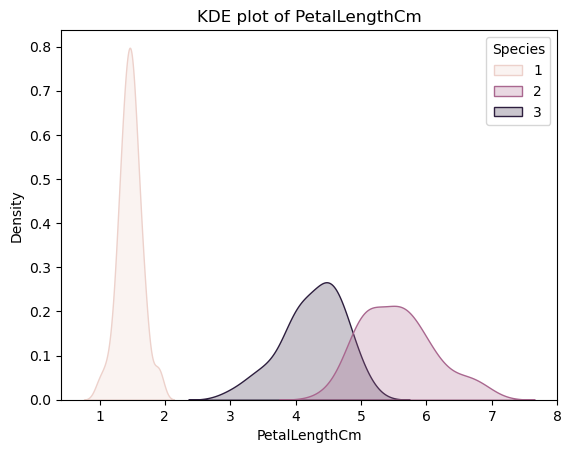

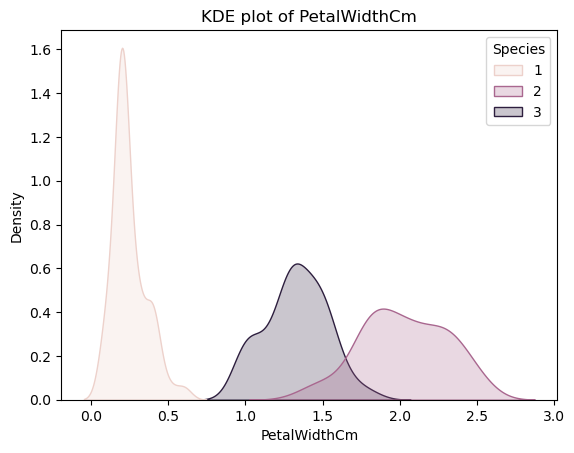

In [57]:
for col in data.columns[:4]:
    sns.kdeplot(data = data, x = col, hue = 'Species', fill = True)
    plt.title(f"KDE plot of {col}")
    plt.show()

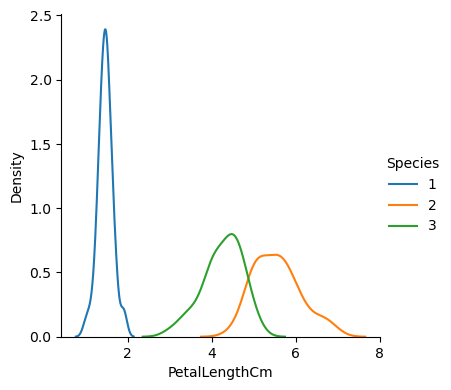

In [62]:
sns.FacetGrid(data, hue = 'Species', height = 4).map(sns.kdeplot, 'PetalLengthCm').add_legend()
plt.show()

Model selection

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier

In [65]:
data.shape

(150, 5)

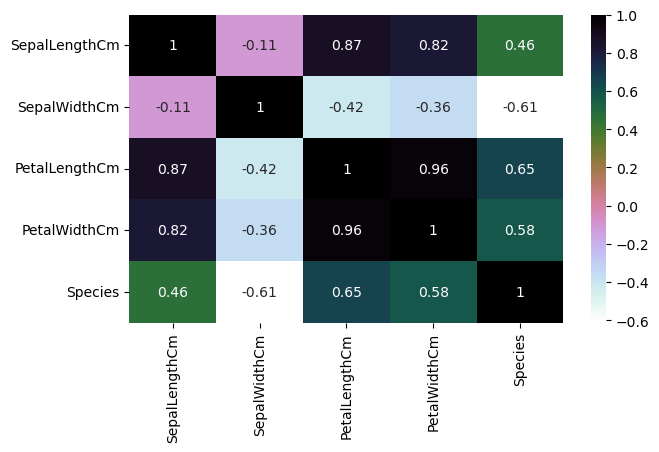

In [66]:
plt.figure(figsize= (7,4))
sns.heatmap(data.corr(), annot = True, cmap ='cubehelix_r')
plt.show()

Observation--->

The Sepal Width and Length are not correlated The Petal Width and Length are highly correlated

Splitting the data into training and testing dataset

In [71]:
X = data.drop('Species', axis= 1)
y = data['Species']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state= 42)

In [80]:
print(X_train.shape) ; print(X_test.shape)
print(y_train.shape) ; print(y_test.shape)


(112, 4)
(38, 4)
(112,)
(38,)


Support Vector Machine

In [86]:
model = svm.SVC()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print('The Accuracy Score of SVM is: ', metrics.accuracy_score(y_test, prediction))


The Accuracy Score of SVM is:  1.0


Logistic Regression

In [88]:
model = LogisticRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('The Accuracy Score of LogisticRegression is: ', metrics.accuracy_score(y_test, pred))


The Accuracy Score of LogisticRegression is:  1.0


Decision Tree

In [89]:
dmodel = DecisionTreeClassifier()
dmodel.fit(X_train, y_train)
p = dmodel.predict(X_test)
print('The Accuracy Score of Decision Tree classifier is: ', metrics.accuracy_score(y_test, p))

The Accuracy Score of Decision Tree classifier is:  1.0


K-Nearest Neighbours

In [91]:
knnmodel = KNeighborsClassifier(n_neighbors= 3)
knnmodel.fit(X_train, y_train)
pr = knnmodel.predict(X_test)
print('The Accuracy Score of KNN is: ', metrics.accuracy_score(y_test, pr))


The Accuracy Score of KNN is:  1.0


In [96]:
acc = []
for i in range(1, 11):
    knnmodel = KNeighborsClassifier(n_neighbors= i)
    knnmodel.fit(X_train, y_train)
    pr = knnmodel.predict(X_test)
    acc.append(metrics.accuracy_score(y_test, pr))
print(acc)

[1.0, 1.0, 1.0, 1.0, 1.0, 0.9736842105263158, 1.0, 1.0, 1.0, 1.0]


We used all the features of iris in above models. Now we will use Petals and Sepals Seperately

In [103]:
petal = data[['PetalLengthCm', 'PetalWidthCm', 'Species']]
sepal = data[['SepalLengthCm', 'SepalWidthCm', 'Species']]

In [105]:
p_train, p_test = train_test_split(petal, test_size = 0.3, random_state = 0)
x_p_train = p_train[['PetalLengthCm', 'PetalWidthCm']]
y_p_train = p_train.Species
x_p_test = p_test[['PetalLengthCm', 'PetalWidthCm']]
y_p_test = p_test.Species

In [106]:
s_train, s_test = train_test_split(sepal, test_size = 0.3, random_state = 0)
x_s_train = s_train[['SepalLengthCm', 'SepalWidthCm']]
y_s_train = s_train.Species
x_s_test = s_test[['SepalLengthCm', 'SepalWidthCm']]
y_s_test = s_test.Species

Support Vector Machine

In [108]:
model = svm.SVC()
model.fit(x_p_train, y_p_train)
pr = model.predict(x_p_test)
print('The Accuracy Score of SVC for petal is: ', metrics.accuracy_score(y_p_test, pr))

model.fit(x_s_train, y_s_train)
ps = model.predict(x_s_test)
print('The Accuracy Score of SVC for sepal is: ', metrics.accuracy_score(y_p_test, ps))

The Accuracy Score of SVC for petal is:  0.9777777777777777
The Accuracy Score of SVC for sepal is:  0.8


Logistic Regression

In [109]:
model = LogisticRegression()
model.fit(x_p_train, y_p_train)
pr = model.predict(x_p_test)
print('The Accuracy Score of SVC for petal is: ', metrics.accuracy_score(y_p_test, pr))

model.fit(x_s_train, y_s_train)
ps = model.predict(x_s_test)
print('The Accuracy Score of SVC for sepal is: ', metrics.accuracy_score(y_p_test, ps))

The Accuracy Score of SVC for petal is:  0.9777777777777777
The Accuracy Score of SVC for sepal is:  0.8222222222222222


Decision Tree Classifier

In [110]:
model = DecisionTreeClassifier()
model.fit(x_p_train, y_p_train)
pr = model.predict(x_p_test)
print('The Accuracy Score of SVC for petal is: ', metrics.accuracy_score(y_p_test, pr))

model.fit(x_s_train, y_s_train)
ps = model.predict(x_s_test)
print('The Accuracy Score of SVC for sepal is: ', metrics.accuracy_score(y_p_test, ps))

The Accuracy Score of SVC for petal is:  0.9777777777777777
The Accuracy Score of SVC for sepal is:  0.6666666666666666


K-Nearest Neighbors

In [111]:
model = KNeighborsClassifier(n_neighbors= 5)
model.fit(x_p_train, y_p_train)
pr = model.predict(x_p_test)
print('The Accuracy Score of SVC for petal is: ', metrics.accuracy_score(y_p_test, pr))

model.fit(x_s_train, y_s_train)
ps = model.predict(x_s_test)
print('The Accuracy Score of SVC for sepal is: ', metrics.accuracy_score(y_p_test, ps))

The Accuracy Score of SVC for petal is:  0.9777777777777777
The Accuracy Score of SVC for sepal is:  0.7555555555555555


#### Observations:
Using Petals over Sepal for training the data gives a much better accuracy.
This was expected as we saw in the heatmap above that the correlation between the Sepal Width and Length was very low whereas the correlation between Petal Width and Length was very high.